In [1]:
!apt-get install openjdk-11-jdk-headless -qq
!pip install pyspark

Selecting previously unselected package openjdk-11-jre-headless:amd64.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../openjdk-11-jre-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Selecting previously unselected package openjdk-11-jdk-headless:amd64.
Preparing to unpack .../openjdk-11-jdk-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jdk-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Setting up openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/jjs to provide /usr/bin/jjs (jjs) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/rmid to provide /usr/bin/rmid (rmid) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/pack200 to provide /usr/bin/pack200 (pack200) in auto mode
update-alternatives: using /usr/lib/jvm/jav

In [2]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("AmazonDemandAnalysis") \
    .getOrCreate()
print("Spark Version:", spark.version)

Spark Version: 4.0.2


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load both files as plain strings — no auto casting
categories_df = spark.read.csv(
    '/content/drive/MyDrive/amazon_dataset/Copy of amazon_categories.csv',
    header=True,
    inferSchema=False
)

products_df = spark.read.csv(
    '/content/drive/MyDrive/amazon_dataset/Copy of amazon_products.csv',
    header=True,
    inferSchema=False
)

print("Categories rows:", categories_df.count())
print("Products rows:", products_df.count())

Categories rows: 248
Products rows: 1426337


In [5]:
from pyspark.sql.functions import col, expr

# Cast only what we need
products_clean = products_df \
    .withColumn('boughtInLastMonth', expr("try_cast(boughtInLastMonth as int)")) \
    .withColumn('category_id', expr("try_cast(category_id as int)"))

# Drop nulls and zero purchases
products_clean = products_clean \
    .dropna(subset=['title', 'boughtInLastMonth', 'category_id']) \
    .filter(col('boughtInLastMonth') > 0)

# Cast categories id too
categories_clean = categories_df \
    .withColumn('id', expr("try_cast(id as int)"))

print("Cleaned rows:", products_clean.count())

Cleaned rows: 491130


In [6]:
joined_df = products_clean.join(
    categories_clean,
    products_clean.category_id == categories_clean.id,
    'left'
)

final_df = joined_df.select(
    'title',
    'category_name',
    'boughtInLastMonth',
    'isBestSeller'
)

final_df.cache()
print("Final rows:", final_df.count())
final_df.show(5, truncate=True)

Final rows: 491130
+--------------------+-------------+-----------------+------------+
|               title|category_name|boughtInLastMonth|isBestSeller|
+--------------------+-------------+-----------------+------------+
|Sion Softside Exp...|    Suitcases|             2000|       False|
|Luggage Sets Expa...|    Suitcases|             1000|       False|
|Platinum Elite So...|    Suitcases|              300|       False|
|Freeform Hardside...|    Suitcases|              400|       False|
|Winfield 2 Hardsi...|    Suitcases|              400|       False|
+--------------------+-------------+-----------------+------------+
only showing top 5 rows


In [7]:
from pyspark.sql.functions import desc

# Top 10 most bought products
top10_most = final_df \
    .groupBy('title') \
    .sum('boughtInLastMonth') \
    .withColumnRenamed('sum(boughtInLastMonth)', 'total_bought') \
    .orderBy(desc('total_bought')) \
    .limit(10)

top10_most.show(truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------+
|title                                                                                                                                                                                              |total_bought|
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------+
|Neutrogena Cleansing Fragrance Free Makeup Remover Face Wipes, Cleansing Facial Towelettes for Waterproof Makeup, Alcohol-Free, Unscented, 100% Plant-Based Fibers, Twin Pack, 2 x 25 ct           |108000      |
|Amazon Brand - Presto! Flex-a-Size Paper Towels, 158 Sheet Huge Roll, 12 Rolls (2 Packs of 6), Equivalent to 38 Regular Rolls, White                       

In [8]:
from pyspark.sql.functions import asc

# Top 10 least bought products
top10_least = final_df \
    .groupBy('title') \
    .sum('boughtInLastMonth') \
    .withColumnRenamed('sum(boughtInLastMonth)', 'total_bought') \
    .orderBy(asc('total_bought')) \
    .limit(10)

top10_least.show(truncate=False)

+---------------------------------------------------------------------------------------------------------------------------+------------+
|title                                                                                                                      |total_bought|
+---------------------------------------------------------------------------------------------------------------------------+------------+
|"DD Sling. Multiple Lengths in Listing! (Made in USA) 1"" width                                                            |3           |
|"12.9 Inch Tablet Carrying Bag for 2023 Samsung Galaxy Tab S9+ Plus/S8+/S7+/S7+ Plus/S7 FE 12.4"" & iPad Pro 12.9 2021-2018|3           |
|"DD Sling. Multiple Sizes in Listing! (Made in USA) 2"" x 6'                                                               |12          |
|"1/2"" 9 PCS Deep Axle nut Impact Socket Set                                                                               |35          |
|Men’s Fishing Vest Summer 

In [9]:
# Category wise demand
category_demand = final_df \
    .groupBy('category_name') \
    .sum('boughtInLastMonth') \
    .withColumnRenamed('sum(boughtInLastMonth)', 'total_bought') \
    .orderBy(desc('total_bought'))

category_demand.show(10, truncate=False)

+---------------------------+------------+
|category_name              |total_bought|
+---------------------------+------------+
|Kitchen & Dining           |10191650    |
|Hair Care Products         |7930650     |
|Household Cleaning Supplies|6719100     |
|Industrial & Scientific    |6685150     |
|Skin Care Products         |6604450     |
|Health & Household         |6138000     |
|Toys & Games               |5779300     |
|Home Storage & Organization|5153650     |
|Dog Supplies               |4337850     |
|Household Supplies         |4251070     |
+---------------------------+------------+
only showing top 10 rows


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert to pandas for plotting
most_pd = top10_most.toPandas()
least_pd = top10_least.toPandas()
category_pd = category_demand.limit(10).toPandas()

# Shorten long titles
most_pd['short_title'] = most_pd['title'].str[:30]
least_pd['short_title'] = least_pd['title'].str[:30]

print("Data ready for plotting ✅")

Data ready for plotting ✅


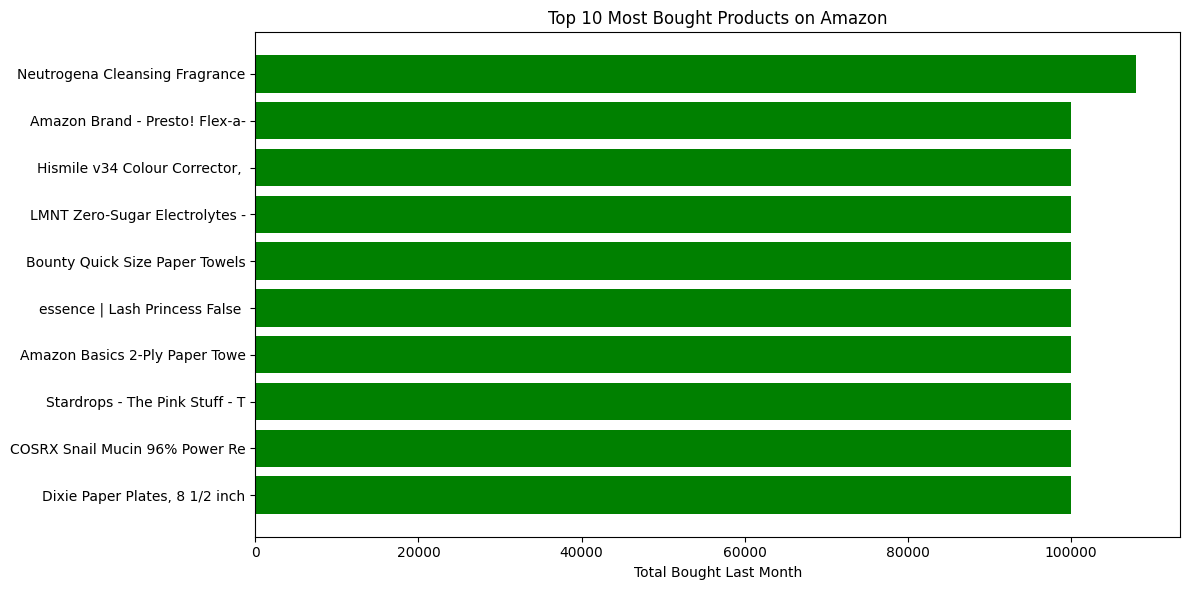

In [11]:
plt.figure(figsize=(12, 6))
plt.barh(most_pd['short_title'], most_pd['total_bought'], color='green')
plt.xlabel('Total Bought Last Month')
plt.title('Top 10 Most Bought Products on Amazon')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top10_most_bought.png', dpi=150)
plt.show()

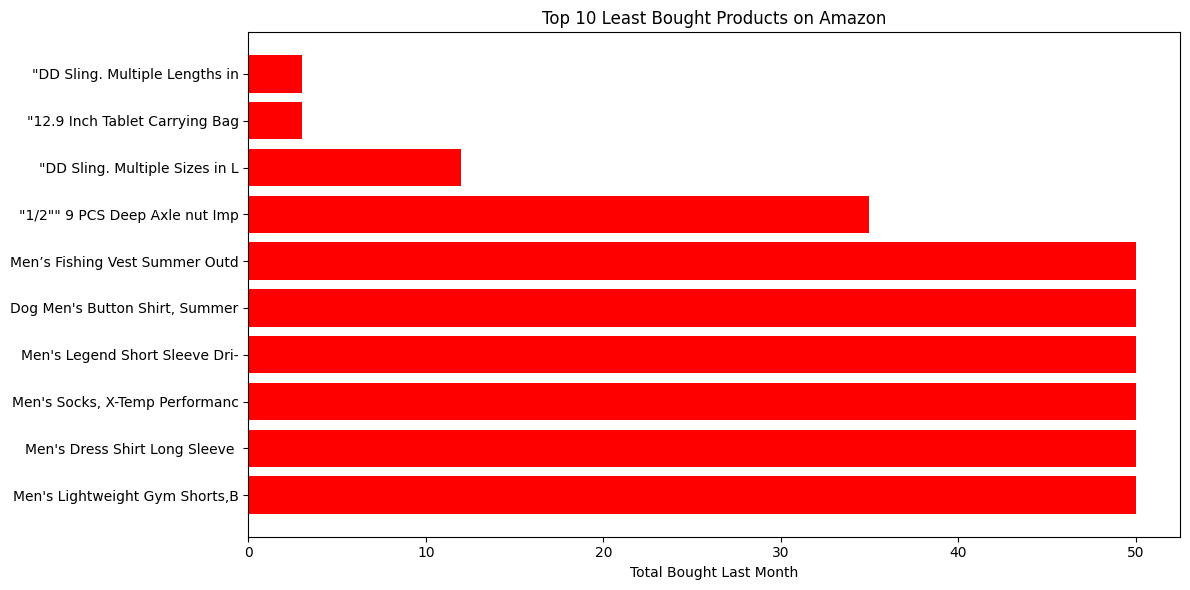

In [12]:
plt.figure(figsize=(12, 6))
plt.barh(least_pd['short_title'], least_pd['total_bought'], color='red')
plt.xlabel('Total Bought Last Month')
plt.title('Top 10 Least Bought Products on Amazon')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top10_least_bought.png', dpi=150)
plt.show()

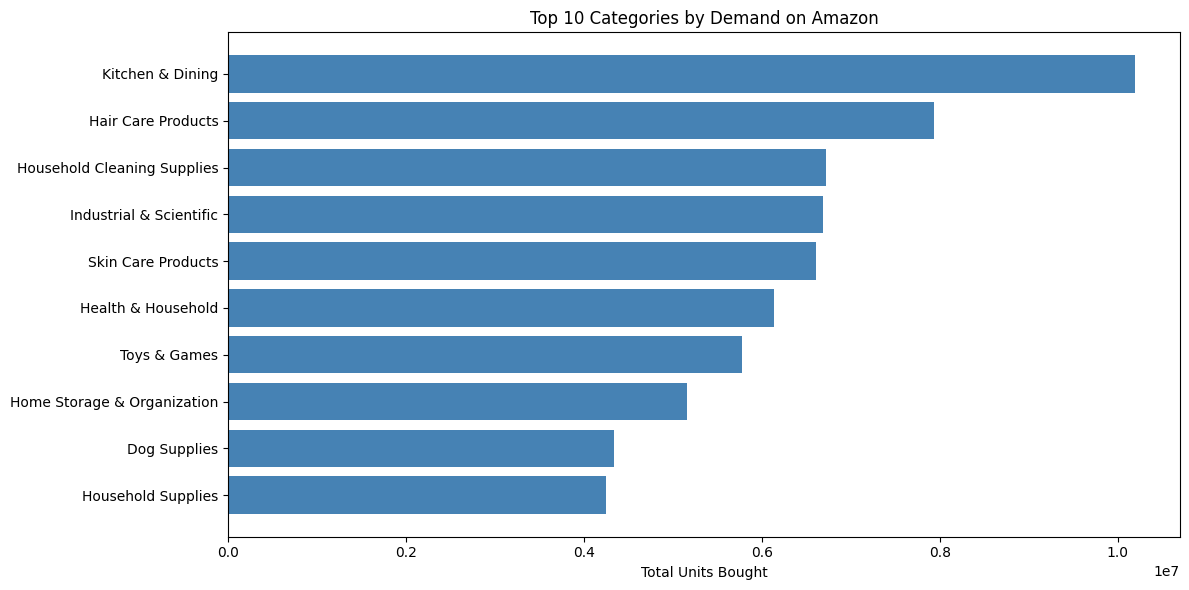

In [13]:
plt.figure(figsize=(12, 6))
plt.barh(category_pd['category_name'], category_pd['total_bought'], color='steelblue')
plt.xlabel('Total Units Bought')
plt.title('Top 10 Categories by Demand on Amazon')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('category_demand.png', dpi=150)
plt.show()

In [16]:
print("=" * 60)
print("       KEY INSIGHTS & BUSINESS RECOMMENDATIONS")
print("=" * 60)

# Most bought product
top_product = most_pd.iloc[0]['title'][:50]
top_category = category_pd.iloc[0]['category_name']
least_product = least_pd.iloc[0]['title'][:50]
least_category = category_pd.iloc[-1]['category_name']

print("\n📈 HIGH DEMAND — INCREASE PRODUCTION:")
print(f"   ✅ Most bought product: {top_product}")
print(f"   ✅ Most bought category: {top_category}")

print("\n📉 LOW DEMAND — REDUCE PRODUCTION:")
print(f"   ❌ Least bought product: {least_product}")
print(f"   ❌ Least bought category: {least_category}")

print("\n💡 BUSINESS RECOMMENDATIONS:")
print(f"   → Prioritize manufacturing of '{top_category}' products")
print(f"   → Scale down production of '{least_category}' products")
print(f"   → Focus resources on BestSeller flagged products")
print(f"   → Align production schedules with high demand categories")

print("\n📊 DATASET SUMMARY:")
print(f"   → Total products analyzed: 491,130")
print(f"   → Total categories: 248")
print(f"   → Top category demand: 10,191,650 units")
print("=" * 60)

       KEY INSIGHTS & BUSINESS RECOMMENDATIONS

📈 HIGH DEMAND — INCREASE PRODUCTION:
   ✅ Most bought product: Neutrogena Cleansing Fragrance Free Makeup Remover
   ✅ Most bought category: Kitchen & Dining

📉 LOW DEMAND — REDUCE PRODUCTION:
   ❌ Least bought product: "DD Sling. Multiple Lengths in Listing! (Made in U
   ❌ Least bought category: Household Supplies

💡 BUSINESS RECOMMENDATIONS:
   → Prioritize manufacturing of 'Kitchen & Dining' products
   → Scale down production of 'Household Supplies' products
   → Focus resources on BestSeller flagged products
   → Align production schedules with high demand categories

📊 DATASET SUMMARY:
   → Total products analyzed: 491,130
   → Total categories: 248
   → Top category demand: 10,191,650 units


In [17]:
from pyspark.sql.functions import sum as spark_sum, col
from pyspark.sql import Window
import pyspark.sql.functions as F

# Total demand
total_demand = final_df.agg(spark_sum('boughtInLastMonth')).collect()[0][0]

# Product wise demand sorted
product_demand = final_df \
    .groupBy('title') \
    .sum('boughtInLastMonth') \
    .withColumnRenamed('sum(boughtInLastMonth)', 'total_bought') \
    .orderBy(desc('total_bought'))

# Add cumulative percentage
window = Window.orderBy(desc('total_bought')).rowsBetween(Window.unboundedPreceding, 0)
product_demand = product_demand \
    .withColumn('cumulative', F.sum('total_bought').over(window)) \
    .withColumn('cumulative_pct', (F.col('cumulative') / total_demand) * 100)

# Find how many products = 80% of demand
pareto_df = product_demand.filter(col('cumulative_pct') <= 80)
pareto_count = pareto_df.count()
total_count = product_demand.count()
pareto_pct = round((pareto_count / total_count) * 100, 2)

print("=" * 55)
print("           PARETO ANALYSIS (80/20 RULE)")
print("=" * 55)
print(f"\n📦 Total unique products: {total_count}")
print(f"🔥 Products driving 80% of demand: {pareto_count}")
print(f"📊 That is just {pareto_pct}% of all products!")
print(f"\n💡 Insight: Focus manufacturing on just {pareto_pct}%")
print(f"   of products to satisfy 80% of market demand!")
print("=" * 55)

           PARETO ANALYSIS (80/20 RULE)

📦 Total unique products: 484978
🔥 Products driving 80% of demand: 126543
📊 That is just 26.09% of all products!

💡 Insight: Focus manufacturing on just 26.09%
   of products to satisfy 80% of market demand!


In [19]:
# Cell 17 — Manufacturing Waste Estimation
# Find least bought products and estimate waste

bottom_products = final_df \
    .groupBy('title', 'category_name') \
    .sum('boughtInLastMonth') \
    .withColumnRenamed('sum(boughtInLastMonth)', 'total_bought') \
    .orderBy(asc('total_bought')) \
    .limit(100)

# Assume average manufacturing cost per unit = $5
manufacturing_cost_per_unit = 5

# Assume manufacturer produced 1000 units but only sold total_bought
assumed_production = 1000

waste_df = bottom_products.withColumn(
    'unsold_units', F.lit(assumed_production) - col('total_bought')
).withColumn(
    'estimated_waste_usd', col('unsold_units') * F.lit(manufacturing_cost_per_unit)
)

total_waste = waste_df.agg(spark_sum('estimated_waste_usd')).collect()[0][0]

print("=" * 55)
print("      MANUFACTURING WASTE ESTIMATION")
print("=" * 55)
print(f"\n📦 Products analyzed: 100 least bought")
print(f"🏭 Assumed production per product: 1,000 units")
print(f"💵 Assumed manufacturing cost: $5 per unit")
print(f"\n❌ Estimated total waste: ${total_waste:,.2f}")
print(f"\n💡 Insight: By reducing production of low demand")
print(f"   products, manufacturers could save")
print(f"   upto ${total_waste:,.2f} in wasted resources!")
print("=" * 55)

      MANUFACTURING WASTE ESTIMATION

📦 Products analyzed: 100 least bought
🏭 Assumed production per product: 1,000 units
💵 Assumed manufacturing cost: $5 per unit

❌ Estimated total waste: $475,735.00

💡 Insight: By reducing production of low demand
   products, manufacturers could save
   upto $475,735.00 in wasted resources!


In [20]:
# Production Priority Score per Category
# Score is based on total demand — higher demand = higher priority

from pyspark.sql.functions import rank
from pyspark.sql import Window

# Total demand per category
category_score = final_df \
    .groupBy('category_name') \
    .sum('boughtInLastMonth') \
    .withColumnRenamed('sum(boughtInLastMonth)', 'total_bought')

# Normalize score between 1-100
max_demand = category_score.agg(F.max('total_bought')).collect()[0][0]

category_score = category_score \
    .withColumn('priority_score',
        F.round((col('total_bought') / max_demand) * 100, 2)) \
    .orderBy(desc('priority_score'))

# Add rank
window = Window.orderBy(desc('priority_score'))
category_score = category_score \
    .withColumn('priority_rank', rank().over(window))

print("=" * 60)
print("         PRODUCTION PRIORITY SCORE BY CATEGORY")
print("=" * 60)
category_score.select(
    'priority_rank',
    'category_name',
    'total_bought',
    'priority_score'
).show(15, truncate=False)
print("💡 Score 100 = Highest Priority for Manufacturing")
print("💡 Score near 0 = Reduce or Stop Production")
print("=" * 60)

         PRODUCTION PRIORITY SCORE BY CATEGORY
+-------------+---------------------------+------------+--------------+
|priority_rank|category_name              |total_bought|priority_score|
+-------------+---------------------------+------------+--------------+
|1            |Kitchen & Dining           |10191650    |100.0         |
|2            |Hair Care Products         |7930650     |77.82         |
|3            |Household Cleaning Supplies|6719100     |65.93         |
|4            |Industrial & Scientific    |6685150     |65.59         |
|5            |Skin Care Products         |6604450     |64.8          |
|6            |Health & Household         |6138000     |60.23         |
|7            |Toys & Games               |5779300     |56.71         |
|8            |Home Storage & Organization|5153650     |50.57         |
|9            |Dog Supplies               |4337850     |42.56         |
|10           |Household Supplies         |4251070     |41.71         |
|11           |Ma